In [134]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [135]:
data = fetch_california_housing()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

In [136]:
class CaliforniaHousingNN(nn.Module):
    def __init__(self, input=8, hidden=[512, 1024], output=1, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input, hidden[0])
        self.bn1 = nn.BatchNorm1d(hidden[0])
        self.fc2 = nn.Linear(hidden[0], hidden[1])
        self.bn2 = nn.BatchNorm1d(hidden[1])
        self.fc3 = nn.Linear(hidden[1], output)
        self.relu = nn.ReLU()
        self.dropout= nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

Epoch 1, Loss 0.7476
Epoch 2, Loss 0.5370
Epoch 3, Loss 0.4832
Epoch 4, Loss 0.4712
Epoch 5, Loss 0.4369
Epoch 6, Loss 0.4153
Epoch 7, Loss 0.4049
Epoch 8, Loss 0.3967
Epoch 9, Loss 0.3942
Epoch 10, Loss 0.3837
Epoch 11, Loss 0.3830
Epoch 12, Loss 0.3732
Epoch 13, Loss 0.3738
Epoch 14, Loss 0.3709
Epoch 15, Loss 0.3584
Epoch 16, Loss 0.3596
Epoch 17, Loss 0.3644
Epoch 18, Loss 0.3620
Epoch 19, Loss 0.3503
Epoch 20, Loss 0.3583
Epoch 21, Loss 0.3510
Epoch 22, Loss 0.3532
Epoch 23, Loss 0.3528
Epoch 24, Loss 0.3520
Epoch 25, Loss 0.3424
Epoch 26, Loss 0.3444
Epoch 27, Loss 0.3333
Epoch 28, Loss 0.3411
Epoch 29, Loss 0.3422
Epoch 30, Loss 0.3425
Epoch 31, Loss 0.3389
Epoch 32, Loss 0.3320
Epoch 33, Loss 0.3326
Epoch 34, Loss 0.3263
Epoch 35, Loss 0.3359
Epoch 36, Loss 0.3291
Epoch 37, Loss 0.3301
Epoch 38, Loss 0.3317
Epoch 39, Loss 0.3305
Epoch 40, Loss 0.3315
Epoch 41, Loss 0.3237
Epoch 42, Loss 0.3219
Epoch 43, Loss 0.3257
Epoch 44, Loss 0.3259
Epoch 45, Loss 0.3206
Epoch 46, Loss 0.32

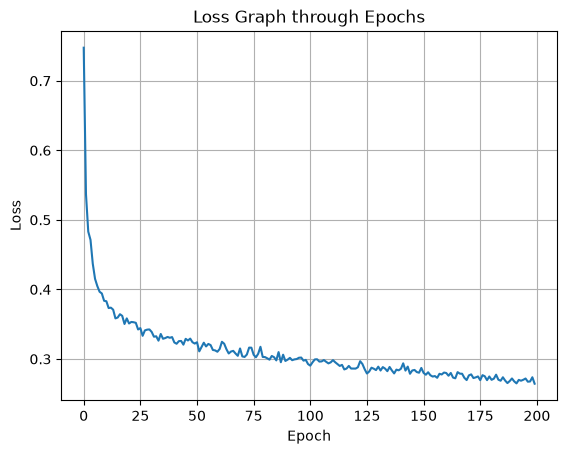

In [ ]:
model = CaliforniaHousingNN()

lf = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

train_losses = []

epochs = 300

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = lf(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}, Loss {avg_loss:.4f}")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Graph through Epochs")
plt.grid(True)
plt.show()

In [138]:
def eval_regression(model, data_loader):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)  # MSE
            total_loss += loss.item() * y_batch.size(0)
            total_samples += y_batch.size(0)
    
    mse = total_loss / total_samples
    rmse = mse ** 0.5
    return mse, rmse

criterion = nn.MSELoss()
mse, rmse = eval_regression(model, test_loader)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 0.2572
RMSE: 0.5072
